# Skincare Sales Analysis

In [2]:
#imports
import pandas as pd
import sqlite3
conn = sqlite3.connect("skincaresales.db")

In [3]:
#loading data
customers = pd.read_csv("Customers.csv")
items = pd.read_csv("Order_items.csv")
orders = pd.read_csv("Orders.csv")
products = pd.read_csv("Products.csv")
returns = pd.read_csv("Returns.csv")
reviews = pd.read_csv("Reviews.csv")

## Datasets Overview

In [4]:
print(customers.shape)

(500, 8)


In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   customer_name        500 non-null    object
 2   city                 500 non-null    object
 3   state                500 non-null    object
 4   gender               500 non-null    object
 5   age_group            500 non-null    object
 6   signup_date          500 non-null    object
 7   acquisition_channel  500 non-null    object
dtypes: object(8)
memory usage: 31.4+ KB


In [6]:
customers.head(500)

,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
0,C0001,Ayaan Gupta,Hyderabad,Telangana,Female,35-44,08-09-2023,YouTube
1,C0002,Aarav Sharma,Gurugram,Haryana,Female,25-34,02-02-2023,Instagram
2,C0003,Kavya Kapoor,Noida,Uttar Pradesh,Other,18-24,23-07-2023,Google Search
3,C0004,Karan Mehta,Kochi,Kerala,Other,25-34,07-01-2023,YouTube
4,C0005,Vihaan Sharma,Lucknow,Uttar Pradesh,Male,18-24,11-12-2023,Google Search
...,...,...,...,...,...,...,...,...
495,C0496,Karan Reddy,Pune,Maharashtra,Male,25-34,20-05-2024,YouTube
496,C0497,Aarav Nair,Gurugram,Haryana,Female,18-24,24-02-2024,Google Search
497,C0498,Myra Joshi,Mumbai,Maharashtra,Male,18-24,04-11-2024,Instagram
498,C0499,Arjun Iyer,Noida,Uttar Pradesh,Female,25-34,03-03-2023,Instagram


In [7]:
customers.isnull().sum()

customer_id            0
customer_name          0
city                   0
state                  0
gender                 0
age_group              0
signup_date            0
acquisition_channel    0
dtype: int64

In [8]:
customers.duplicated().sum()

np.int64(0)

In [9]:
print(items.shape)

(2042, 7)


In [10]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2042 non-null   object 
 1   order_id       2042 non-null   object 
 2   product_id     2042 non-null   object 
 3   quantity       2042 non-null   int64  
 4   unit_price     2042 non-null   int64  
 5   discount_pct   2042 non-null   int64  
 6   item_total     2042 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 111.8+ KB


In [11]:
items.head(3000)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total
0,OI000001,O00001,P023,1,499,15,424.15
1,OI000002,O00002,P020,1,349,0,349.00
2,OI000003,O00003,P001,2,549,10,988.20
3,OI000004,O00003,P002,1,599,20,479.20
4,OI000005,O00004,P009,2,349,5,663.10
...,...,...,...,...,...,...,...
2037,OI002038,O01249,P014,1,499,20,399.20
2038,OI002039,O01249,P011,2,349,15,593.30
2039,OI002040,O01249,P006,2,599,10,1078.20
2040,OI002041,O01250,P014,1,499,15,424.15


In [12]:
items.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
discount_pct     0
item_total       0
dtype: int64

In [13]:
items.duplicated().sum()

np.int64(0)

In [14]:
print(orders.shape)

(1250, 11)


In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         1250 non-null   object 
 1   customer_id      1250 non-null   object 
 2   order_date       1250 non-null   object 
 3   order_status     1250 non-null   object 
 4   payment_method   1250 non-null   object 
 5   sales_channel    1250 non-null   object 
 6   gross_amount     1250 non-null   float64
 7   discount_amount  1250 non-null   float64
 8   shipping_fee     1250 non-null   int64  
 9   final_amount     1250 non-null   float64
 10  delivered_date   1099 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 107.6+ KB


In [16]:
orders.head(65)

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
0,O00001,C0047,10-06-2024,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,14-06-2024
1,O00002,C0016,18-02-2025,Delivered,Credit Card,Website,349.00,0.00,40,389.00,21-02-2025
2,O00003,C0191,03-12-2025,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,09-12-2025
3,O00004,C0087,10-08-2025,Delivered,Credit Card,Website,663.10,34.90,49,712.10,17-08-2025
4,O00005,C0211,17-07-2025,Delivered,UPI,Website,1511.35,134.65,0,1511.35,23-07-2025
...,...,...,...,...,...,...,...,...,...,...,...
60,O00061,C0080,14-11-2024,Delivered,COD,Mobile App,855.70,92.30,0,855.70,17-11-2024
61,O00062,C0207,04-04-2024,Returned,Debit Card,Website,359.10,39.90,59,418.10,10-04-2024
62,O00063,C0125,10-02-2024,Delivered,COD,Marketplace,319.20,79.80,49,368.20,15-02-2024
63,O00064,C0250,14-02-2024,Delivered,UPI,Website,224.10,24.90,59,283.10,16-02-2024


In [17]:
orders.isnull().sum()

order_id             0
customer_id          0
order_date           0
order_status         0
payment_method       0
sales_channel        0
gross_amount         0
discount_amount      0
shipping_fee         0
final_amount         0
delivered_date     151
dtype: int64

In [18]:
orders.duplicated().sum()

np.int64(0)

In [19]:
print(products.shape)

(28, 11)


In [20]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      28 non-null     object
 1   product_name    28 non-null     object
 2   category        28 non-null     object
 3   concern         28 non-null     object
 4   skin_type       28 non-null     object
 5   key_ingredient  28 non-null     object
 6   size            28 non-null     object
 7   mrp             28 non-null     int64 
 8   cost_price      28 non-null     int64 
 9   stock_qty       28 non-null     int64 
 10  launch_date     28 non-null     object
dtypes: int64(3), object(8)
memory usage: 2.5+ KB


In [21]:
products.head(65)

,product_id,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,P001,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,15-01-2022
1,P002,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
2,P003,Vitamin C 10% Face Serum,Serum,Brightening,All Skin Types,Vitamin C,30ml,699,315,180,01-05-2022
3,P004,Alpha Arbutin 2% Serum,Serum,Pigmentation,All Skin Types,Alpha Arbutin,30ml,649,292,160,18-03-2022
4,P005,Retinol 0.3% Face Serum,Serum,Anti-Ageing,Normal / Dry,Retinol,30ml,699,318,140,11-08-2022
5,P006,Hyaluronic Acid 2% Serum,Serum,Hydration,Dry / Dehydrated,Hyaluronic Acid,30ml,599,258,210,05-12-2021
6,P007,AHA BHA 10% Exfoliating Serum,Serum,Exfoliation,Oily / Combination,AHA + BHA,30ml,699,322,130,20-02-2023
7,P008,Granactive Retinoid 2% Serum,Serum,Anti-Ageing,Normal / Mature,Retinoid,30ml,799,358,120,12-05-2023
8,P009,Ceramide Moisturizer,Moisturizer,Barrier Repair,Dry / Sensitive,Ceramide,50g,349,145,300,01-10-2022
9,P010,Vitamin B5 Moisturizer,Moisturizer,Hydration,All Skin Types,Vitamin B5,50g,399,162,280,22-04-2022


In [22]:
products.isnull().sum()

product_id        0
product_name      0
category          0
concern           0
skin_type         0
key_ingredient    0
size              0
mrp               0
cost_price        0
stock_qty         0
launch_date       0
dtype: int64

In [23]:
products.duplicated().sum()

np.int64(0)

In [24]:
print(returns.shape)

(79, 6)


In [25]:
returns.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      79 non-null     object
 1   order_id       79 non-null     object
 2   product_id     79 non-null     object
 3   return_date    79 non-null     object
 4   return_reason  79 non-null     object
 5   refund_status  79 non-null     object
dtypes: object(6)
memory usage: 3.8+ KB


In [26]:
returns.head(5)

,return_id,order_id,product_id,return_date,return_reason,refund_status
0,R00001,O00011,P003,31-03-2024,Late delivery,Under Review
1,R00002,O00023,P007,17-05-2025,Skin irritation,Replacement Sent
2,R00003,O00032,P024,18-07-2024,Skin irritation,Refunded
3,R00004,O00062,P027,10-04-2024,Changed mind,Under Review
4,R00005,O00130,P017,26-08-2024,Skin irritation,Replacement Sent


In [27]:
returns.isnull().sum()

return_id        0
order_id         0
product_id       0
return_date      0
return_reason    0
refund_status    0
dtype: int64

In [28]:
returns.duplicated().sum()

np.int64(0)

In [29]:
print(reviews.shape)

(494, 6)


In [30]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    494 non-null    object
 1   customer_id  494 non-null    object
 2   product_id   494 non-null    object
 3   order_id     494 non-null    object
 4   rating       494 non-null    int64 
 5   review_date  494 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.3+ KB


In [31]:
reviews.head(65)

,review_id,customer_id,product_id,order_id,rating,review_date
0,RV00001,C0047,P023,O00001,4,19-06-2024
1,RV00002,C0191,P001,O00003,5,08-12-2025
2,RV00003,C0087,P009,O00004,5,29-08-2025
3,RV00004,C0289,P007,O00009,1,17-06-2024
4,RV00005,C0476,P016,O00012,3,04-10-2025
...,...,...,...,...,...,...
60,RV00061,C0464,P022,O00186,3,25-02-2025
61,RV00062,C0496,P024,O00188,2,18-02-2025
62,RV00063,C0061,P004,O00190,5,17-08-2024
63,RV00064,C0421,P012,O00191,4,04-05-2024


In [32]:
reviews.isnull().sum()

review_id      0
customer_id    0
product_id     0
order_id       0
rating         0
review_date    0
dtype: int64

In [33]:
reviews.duplicated().sum()

np.int64(0)

## Data Cleaning 
* Confirmed data types were appropriate for each column.
* Verified there were no duplicated records found in each table.
* Checked over missing values in each table using isnull().sum() and only found one column (delivery_date) with missing values.
* Left the missing "delivery_date" values as these were not relevant to this analysis.
* Confirmed that column headers across the different tables were consistent.
* Later standardized values during exploratory data analysis for "skin_type" in products table to show consistently (Senisitive / Dry and Dry / sensitive to Dry / sensitive)


## Exploratory Data Analysis

In [34]:
# CUSTOMERS with shared data of customer_id
customers['gender'].value_counts()

gender
Female    181
Male      169
Other     150
Name: count, dtype: int64

In [35]:
customers['age_group'].value_counts()

age_group
25-34    244
18-24    120
35-44     86
45+       50
Name: count, dtype: int64

In [36]:
customers['acquisition_channel'].value_counts()

acquisition_channel
Google Search     148
Instagram         145
YouTube            78
Website Direct     70
Referral           59
Name: count, dtype: int64

In [37]:
#ITEMS with shared order_id

In [38]:
# ORDER with shared data of customer_id and order_id
orders['sales_channel'].value_counts()

sales_channel
Website        698
Mobile App     444
Marketplace    108
Name: count, dtype: int64

In [39]:
orders['order_status'].value_counts()

order_status
Delivered     1020
Cancelled       86
Returned        79
In Transit      65
Name: count, dtype: int64

In [40]:
# products with shared data in product_id 
products['category'].value_counts()

category
Serum          8
Moisturizer    4
Sunscreen      3
Cleanser       3
Hair Care      3
Toner          2
Eye Care       2
Body Care      2
Lip Care       1
Name: count, dtype: int64

In [41]:
products['concern'].value_counts()

concern
Anti-Ageing         3
Hydration           3
Exfoliation         3
Sun Protection      3
Acne Control        2
Dark Circles        1
Body Acne           1
Body Brightening    1
Damage Repair       1
Hair Growth         1
Dandruff Control    1
Nourishment         1
Gentle Cleansing    1
Oil Control         1
Soothing            1
Barrier Repair      1
Pigmentation        1
Brightening         1
Lip Protection      1
Name: count, dtype: int64

In [42]:
products['skin_type'].value_counts()

skin_type
All Skin Types        9
Oily / Acne-Prone     3
Oily / Combination    3
Sensitive             2
Scalp Care            2
Normal / Dry          1
Dry / Dehydrated      1
Normal / Mature       1
Dry / Sensitive       1
Dry                   1
Sensitive / Dry       1
Normal / Oily         1
Mature / Dry          1
Hair Care             1
Name: count, dtype: int64

In [43]:
products['skin_type'] = products['skin_type'].replace ({'Sensitive / Dry': 'Dry / Sensitive'})

In [44]:
products['skin_type'].value_counts()

skin_type
All Skin Types        9
Oily / Acne-Prone     3
Oily / Combination    3
Dry / Sensitive       2
Sensitive             2
Scalp Care            2
Normal / Dry          1
Dry / Dehydrated      1
Normal / Mature       1
Dry                   1
Normal / Oily         1
Mature / Dry          1
Hair Care             1
Name: count, dtype: int64

In [45]:
products['key_ingredient'].value_counts()

key_ingredient
Salicylic Acid         3
Niacinamide            2
SPF 60                 1
Bond Repair Complex    1
Redensyl               1
Piroctone Olamine      1
Peptides               1
Caffeine               1
Rose Water             1
PHA                    1
Glycolic Acid          1
Oat Extract            1
SPF Blend              1
SPF 50                 1
Marula Oil             1
Sepicalm               1
Vitamin B5             1
Ceramide               1
Retinoid               1
AHA + BHA              1
Hyaluronic Acid        1
Retinol                1
Alpha Arbutin          1
Vitamin C              1
SPF 30                 1
Name: count, dtype: int64

In [46]:
# returns with shared data in product_id and order_id
returns['return_reason'].value_counts()

return_reason
Skin irritation        28
Late delivery          16
Damaged packaging      13
Wrong item received    12
Changed mind           10
Name: count, dtype: int64

In [47]:
# reviews with shared data in customer_id, product_id, and order_id
reviews['rating'].value_counts()

rating
5    193
4    163
3     70
2     39
1     29
Name: count, dtype: int64

## SQL Analysis

In [48]:
products.to_sql ("products", conn, if_exists = "replace", index = False)
items.to_sql ("items", conn, if_exists = "replace", index = False)
reviews.to_sql ("reviews", conn, if_exists = "replace", index = False)
returns.to_sql ("returns", conn, if_exists = "replace", index = False)
orders.to_sql ("orders", conn, if_exists = "replace", index = False)
customers.to_sql("customers", conn, if_exists = "replace", index = False)

500

In [49]:
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"
existing_tables = pd.read_sql_query(tables_query, conn)
print("Available tables:")
print(existing_tables)

Available tables:
               name
0  skincaresales.db
1          products
2             items
3           reviews
4           returns
5            orders
6         customers


### What types of products are the most and least purchased in the company?

In [50]:
print(items.columns)

Index(['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price',
       'discount_pct', 'item_total'],
      dtype='object')


In [51]:
print(products.columns)

Index(['product_id', 'product_name', 'category', 'concern', 'skin_type',
       'key_ingredient', 'size', 'mrp', 'cost_price', 'stock_qty',
       'launch_date'],
      dtype='object')


In [52]:
print(reviews.columns)

Index(['review_id', 'customer_id', 'product_id', 'order_id', 'rating',
       'review_date'],
      dtype='object')


In [53]:
products.category.value_counts()

category
Serum          8
Moisturizer    4
Sunscreen      3
Cleanser       3
Hair Care      3
Toner          2
Eye Care       2
Body Care      2
Lip Care       1
Name: count, dtype: int64

In [54]:
query = """
SELECT products.category, SUM(items.quantity) AS units_purchased 
FROM items
JOIN products
ON items.product_id = products.product_id
GROUP BY products.category
ORDER BY units_purchased DESC;
"""
result = pd.read_sql_query (query, conn)
result

,category,units_purchased
0,Serum,919
1,Moisturizer,443
2,Sunscreen,314
3,Cleanser,286
4,Hair Care,216
5,Body Care,128
6,Eye Care,111
7,Lip Care,82
8,Toner,80


#### This query identifies categories that are leading in purchases in the company by summming units purchased across the different categories (serums, moisturizers, sunscreen, etc). When it come to skincare category, serums (919 units) are contributing the most to sales followed by moisturizers (443 units) and sunscreen (314). 

In [92]:
# SET TO GO
query = """
SELECT products.product_name, products.category, products.concern, products.key_ingredient, COUNT (items.order_id) as order_count, SUM(items.quantity) AS units_purchased
FROM items
JOIN products 
ON items.product_id = products.product_id
GROUP BY products.product_name
ORDER BY units_purchased DESC;
"""
result = pd.read_sql_query (query, conn)
result

,product_name,category,concern,key_ingredient,order_count,units_purchased
0,Alpha Arbutin 2% Serum,Serum,Pigmentation,Alpha Arbutin,131,166
1,10% Niacinamide Face Serum,Serum,Oil Control,Niacinamide,109,144
2,SPF 60 PA++++ Sunscreen,Sunscreen,Sun Protection,SPF 60,105,138
3,Hyaluronic Acid 2% Serum,Serum,Hydration,Hyaluronic Acid,101,132
4,Ceramide Moisturizer,Moisturizer,Barrier Repair,Ceramide,100,124
5,Marula Oil 5% Moisturizer,Moisturizer,Nourishment,Marula Oil,88,116
6,Vitamin C 10% Face Serum,Serum,Brightening,Vitamin C,89,115
7,Glycolic Acid Face Cleanser,Cleanser,Exfoliation,Glycolic Acid,93,115
8,2% Salicylic Acid Face Serum,Serum,Acne Control,Salicylic Acid,89,111
9,Vitamin B5 Moisturizer,Moisturizer,Hydration,Vitamin B5,93,108


#### This query identifies the number of purchases for each of the 28 products offered by the skincare company. This was done through summing the quantities if units purchased across all orders. The most purchased type of skincare was alpha arbutin serum for pigmentation (166 units purchased) followed by niacinamide serum (144 units), SPF 60 sunscreen (138 units), and hyaluronic acid serum for hydration (132 units). The least purchased was an alcohol free toner (34 units), multi-peptide eye cream for anti-ageing (39 units), and rose water hydrating toner (46 units).

In [56]:
#Q1 Query Validation
query = """
SELECT
    SUM(units_purchased)
FROM (
    SELECT products.product_name, products.category, products.concern, products.key_ingredient, SUM(items.quantity) AS units_purchased
    FROM items
    JOIN products 
    ON items.product_id = products.product_id
    GROUP BY products.product_name
    ORDER BY units_purchased DESC);
"""
result = pd.read_sql_query (query, conn)
result

,SUM(units_purchased)
0,2579


In [57]:
# In the product column, each product appears once.
query = """
SELECT
    product_id,
    COUNT(*) AS occurrences
FROM products
GROUP BY product_id
HAVING COUNT(*) > 1;
"""
result = pd.read_sql_query (query, conn)
result

,product_id,occurrences


In [58]:
# This shows 2042 rows of orders/purchases.
query = """
SELECT COUNT(*)
FROM items
JOIN products
ON items.product_id = products.product_id;
"""
result = pd.read_sql_query (query, conn)
result

,COUNT(*)
0,2042


In [59]:
#COMPARING TOTAL QUANTITIES: Total of units purchased is 2579 which is consistent with the units purchased in the main sql query.
query = """
SELECT SUM(quantity)
FROM items;
"""
result = pd.read_sql_query (query, conn)
result

,SUM(quantity)
0,2579


In [61]:
#Q1B query check
query = """
SELECT 
    SUM(amt_purchased)
FROM (
    SELECT products.product_name, products.category, products.concern, products.key_ingredient, SUM(items.quantity) AS amt_purchased
    FROM items
    JOIN products 
    ON items.product_id = products.product_id
    JOIN orders
    on items.order_id = orders.order_id
    GROUP BY products.category
    ORDER BY amt_purchased DESC);
"""
result = pd.read_sql_query (query, conn)
result

,SUM(amt_purchased)
0,2579


### Most and Least Rated Products in the Skincare Company

In [62]:
reviews.describe()

,rating
count,494.000000
mean,3.914980
std,1.171353
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [95]:
#28 unique products
query = """
SELECT products.product_name, products.category, products.concern, AVG(reviews.rating) AS avg_rating, SUM(reviews.rating) AS number_of_reviews
FROM reviews
JOIN products
ON reviews.product_id = products.product_id 
GROUP BY products.category, products.product_name
ORDER BY avg_rating DESC;
"""
result = pd.read_sql_query (query, conn)
result


,product_name,category,concern,avg_rating,number_of_reviews
0,Vitamin B5 Moisturizer,Moisturizer,Hydration,4.500000,117
1,PHA 3% Alcohol-Free Toner,Toner,Exfoliation,4.428571,31
2,Body Lotion with Niacinamide,Body Care,Body Brightening,4.230769,55
3,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,4.187500,67
4,Glycolic Acid Face Cleanser,Cleanser,Exfoliation,4.185185,113
5,Aqualogica Lightweight Sunscreen,Sunscreen,Sun Protection,4.133333,62
6,Sepicalm 3% Moisturizer,Moisturizer,Soothing,4.125000,66
7,Hyaluronic Acid 2% Serum,Serum,Hydration,4.100000,123
8,Bond Repair Shampoo,Hair Care,Damage Repair,4.071429,57
9,Marula Oil 5% Moisturizer,Moisturizer,Nourishment,4.000000,84


#### This query identifies average ratings across the products sold by the company by averaging the the ratings for each product. The two products with the highest rating are: Vitamin B5 moisturizer (4.5) and PHA 3% Alcohol-free toner (4.43). The two products with the lowest rating are: Body Wash with Salicylic Acid (3.25) and Anti-Dandruff Shampoo for dandruff control (3.28). 

In [65]:
#Q1 Validation
query = """
SELECT SUM(reviews.rating)
FROM reviews;
"""
result = pd.read_sql_query (query, conn)
result

,SUM(reviews.rating)
0,1934


In [66]:
#Q1
query = """
SELECT SUM(number_of_reviews)
FROM (
    SELECT products.product_name, products.category, products.concern, AVG(reviews.rating) AS avg_rating, SUM(reviews.rating) AS number_of_reviews, products.stock_qty, reviews.order_id
    FROM reviews
    JOIN products
    ON reviews.product_id = products.product_id 
    GROUP BY products.category, products.product_name
    ORDER BY products.category, avg_rating DESC);
"""
result = pd.read_sql_query (query, conn)
result

,SUM(number_of_reviews)
0,1934


### What is the main driving factor for returns?

In [99]:
query = """
SELECT products.product_name, products.category, products.concern, returns.return_reason, COUNT(*) AS reason_count, COUNT(returns.product_id) AS product_return
FROM products
JOIN returns
ON returns.product_id = products.product_id 
GROUP BY returns.return_reason, products.product_name
ORDER BY products.category, product_return DESC;
"""
result = pd.read_sql_query (query, conn)
result


,product_name,category,concern,return_reason,reason_count,product_return
0,Body Lotion with Niacinamide,Body Care,Body Brightening,Skin irritation,2,2
1,Body Wash with Salicylic Acid,Body Care,Body Acne,Changed mind,1,1
2,Body Wash with Salicylic Acid,Body Care,Body Acne,Damaged packaging,1,1
3,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,Skin irritation,2,2
4,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,Wrong item received,2,2
5,Salicylic Acid Face Cleanser,Cleanser,Acne Control,Changed mind,1,1
6,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,Damaged packaging,1,1
7,Glycolic Acid Face Cleanser,Cleanser,Exfoliation,Late delivery,1,1
8,Salicylic Acid Face Cleanser,Cleanser,Acne Control,Skin irritation,1,1
9,Caffeine Under Eye Cream,Eye Care,Dark Circles,Damaged packaging,1,1


#### This query identifies the products that have had returns and the amount of returns along with the reasons for it. From the other query table, the highest rated products were vitamin b5 moisturizer (4.5 rating, 2 returns based on skin irritation and changed mind), PHA 3% alcohol toner (4.4 rating and 1 return for skin irritation), and body lotion with niacinamide (4.2 rating, 2 returns for skin irritation). The lowest rated products were rose water hydrating toner (3.5 rating, no recorded returns), anti-dandruff shampoo (3.3 rating, 1 return for wrong item received), and body wash with salicylic acid (3.25 rating, 2 returns for changed mind and damaged packaging). 

In [98]:
query = """
SELECT products.product_name, products.category, products.concern, returns.return_reason, COUNT(returns.return_reason) AS reason_count
FROM products
JOIN returns
ON returns.product_id = products.product_id 
GROUP BY products.category, products.product_name
ORDER BY products.category, reason_count DESC;
"""
result = pd.read_sql_query (query, conn)
result


,product_name,category,concern,return_reason,reason_count
0,Body Wash with Salicylic Acid,Body Care,Body Acne,Changed mind,2
1,Body Lotion with Niacinamide,Body Care,Body Brightening,Skin irritation,2
2,Oat Extract Gentle Cleanser,Cleanser,Gentle Cleansing,Damaged packaging,5
3,Salicylic Acid Face Cleanser,Cleanser,Acne Control,Changed mind,2
4,Glycolic Acid Face Cleanser,Cleanser,Exfoliation,Late delivery,1
5,Caffeine Under Eye Cream,Eye Care,Dark Circles,Damaged packaging,3
6,Hair Growth Actives Serum,Hair Care,Hair Growth,Skin irritation,3
7,Bond Repair Shampoo,Hair Care,Damage Repair,Changed mind,2
8,Anti-Dandruff Shampoo,Hair Care,Dandruff Control,Wrong item received,1
9,Lip Balm SPF 30,Lip Care,Lip Protection,Skin irritation,1


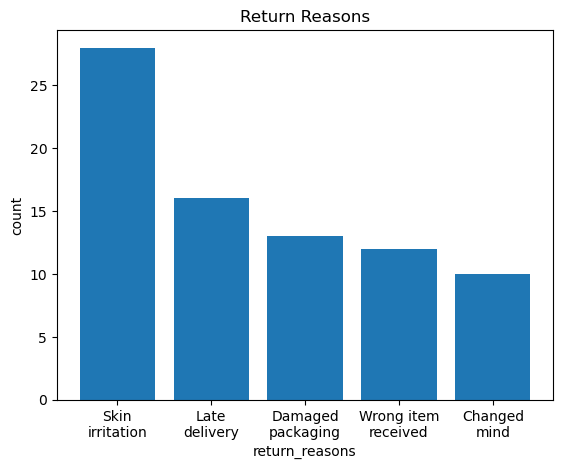

In [69]:
import matplotlib.pyplot as plt
import pandas as pd 
import textwrap

count_data = returns.return_reason.value_counts()

wrapped_labels = [textwrap.fill(label, 10) for label in count_data.index]
plt.xticks(range(len(count_data)), wrapped_labels, rotation=0)

returns = pd.read_csv("Returns.csv")
plt.bar(count_data.index, count_data.values)
plt.title("Return Reasons")
plt.xlabel("return_reasons")
plt.ylabel("count")
plt.show()

In [70]:
returns.return_reason.value_counts()

return_reason
Skin irritation        28
Late delivery          16
Damaged packaging      13
Wrong item received    12
Changed mind           10
Name: count, dtype: int64

#### This query and matplotlib identify and visualize the return reasons and amount of returns made for each product as well as identifying the most common return reasons. The two most common reason of returns have to do with skin irritation and shipping complications including late deliveries (16) and damaged packaing (13) and the wrong item recieved. The total count for these summed return reason involving shipping is 29 followed by skin irritation with 28 returns. 

### Learning about the customers

In [71]:
print(customers.columns)

Index(['customer_id', 'customer_name', 'city', 'state', 'gender', 'age_group',
       'signup_date', 'acquisition_channel'],
      dtype='object')


In [101]:
query = """
SELECT products.product_name, customers.age_group, products.category, products.concern, COUNT(reviews.rating) AS number_of_reviews
FROM customers
JOIN reviews
ON reviews.customer_id = customers.customer_id
JOIN products
ON reviews.product_id = products.product_id
GROUP BY customers.age_group, products.category
ORDER BY customers.age_group, number_of_reviews DESC;
"""
result = pd.read_sql_query(query, conn)
result

,product_name,age_group,category,concern,number_of_reviews
0,10% Niacinamide Face Serum,18-24,Serum,Oil Control,41
1,Oat Extract Gentle Cleanser,18-24,Cleanser,Gentle Cleansing,20
2,Ceramide Moisturizer,18-24,Moisturizer,Barrier Repair,18
3,SPF 60 PA++++ Sunscreen,18-24,Sunscreen,Sun Protection,14
4,Hair Growth Actives Serum,18-24,Hair Care,Hair Growth,12
5,Body Lotion with Niacinamide,18-24,Body Care,Body Brightening,9
6,Multi-Peptide Eye Cream,18-24,Eye Care,Anti-Ageing,4
7,Rose Water Hydrating Toner,18-24,Toner,Hydration,3
8,Lip Balm SPF 30,18-24,Lip Care,Lip Protection,1
9,Retinol 0.3% Face Serum,25-34,Serum,Anti-Ageing,84


In [73]:
customers.age_group.value_counts()

age_group
25-34    244
18-24    120
35-44     86
45+       50
Name: count, dtype: int64

In [74]:
customers.age_group.value_counts(normalize=True*100)

age_group
25-34    0.488
18-24    0.240
35-44    0.172
45+      0.100
Name: proportion, dtype: float64

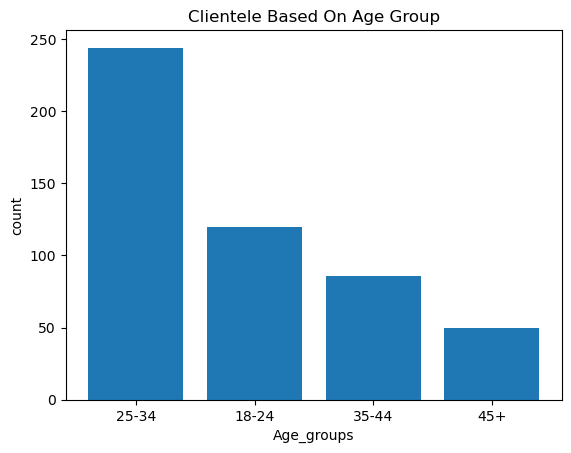

In [75]:
import matplotlib.pyplot as plt
import pandas as pd 

customers = pd.read_csv("Customers.csv")
count_data = customers.age_group.value_counts()
plt.bar(count_data.index, count_data.values)
plt.title("Clientele Based On Age Group")
plt.xlabel("Age_groups")
plt.ylabel("count")
plt.show()

#### The SQL query and matplotlib.pyplot identify and visualize the dominant age group of clientele for the skincare company. People aged 25-35 (49%) make a dominant amount of the clientele followed by 18-24 years old (24%), 35-44 years old (17%), and 45 and over (10%). 

### What regions and acquisition channels are driving customers to the company?

In [76]:
customers.groupby("state")["city"].value_counts(ascending=False)

state           city      
Chandigarh      Chandigarh    21
Delhi           Delhi         25
Gujarat         Surat         29
                Ahmedabad     26
                Vadodara      16
Haryana         Gurugram      30
Karnataka       Bengaluru     28
Kerala          Kochi         31
Madhya Pradesh  Indore        34
                Bhopal        27
Maharashtra     Nagpur        29
                Pune          28
                Mumbai        21
Rajasthan       Jaipur        25
Tamil Nadu      Coimbatore    20
                Chennai       16
Telangana       Hyderabad     18
Uttar Pradesh   Lucknow       33
                Noida         23
West Bengal     Kolkata       20
Name: count, dtype: int64

In [77]:
customers.city.value_counts()

city
Indore        34
Lucknow       33
Kochi         31
Gurugram      30
Nagpur        29
Surat         29
Pune          28
Bengaluru     28
Bhopal        27
Ahmedabad     26
Jaipur        25
Delhi         25
Noida         23
Chandigarh    21
Mumbai        21
Coimbatore    20
Kolkata       20
Hyderabad     18
Vadodara      16
Chennai       16
Name: count, dtype: int64

In [78]:
customers.state.value_counts()

state
Maharashtra       78
Gujarat           71
Madhya Pradesh    61
Uttar Pradesh     56
Tamil Nadu        36
Kerala            31
Haryana           30
Karnataka         28
Rajasthan         25
Delhi             25
Chandigarh        21
West Bengal       20
Telangana         18
Name: count, dtype: int64

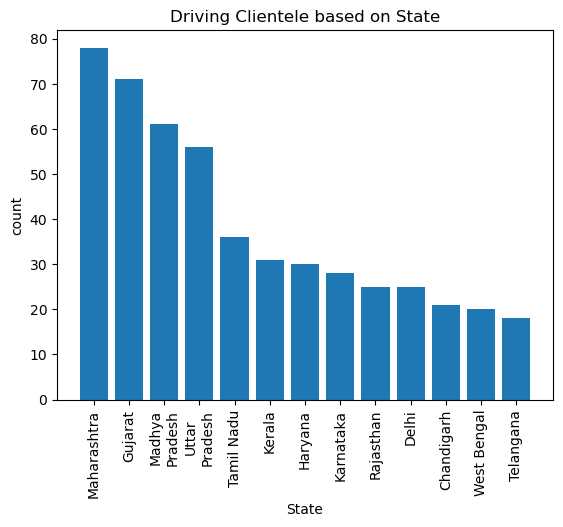

In [79]:
import matplotlib.pyplot as plt
import pandas as pd 

import textwrap

customers = pd.read_csv("Customers.csv")
count_data = customers.state.value_counts()

wrapped_labels = [textwrap.fill(label, 11) for label in count_data.index]
plt.xticks(range(len(count_data)), wrapped_labels, rotation=0)
plt.xticks(rotation=90)

plt.bar(count_data.index, count_data.values)
plt.title("Driving Clientele based on State")
plt.xlabel("State")
plt.ylabel("count")
plt.show()

#### This query and matplotlib identify and visualize where most of the customers are located. The top three state are: Maharashtra (78 customers), Gujarat (71 customers), and Madhya Pradesh (61 customers).

In [80]:
customers.acquisition_channel.value_counts()

acquisition_channel
Google Search     148
Instagram         145
YouTube            78
Website Direct     70
Referral           59
Name: count, dtype: int64

In [81]:
customers.acquisition_channel.value_counts(normalize = True * 100)

acquisition_channel
Google Search     0.296
Instagram         0.290
YouTube           0.156
Website Direct    0.140
Referral          0.118
Name: proportion, dtype: float64

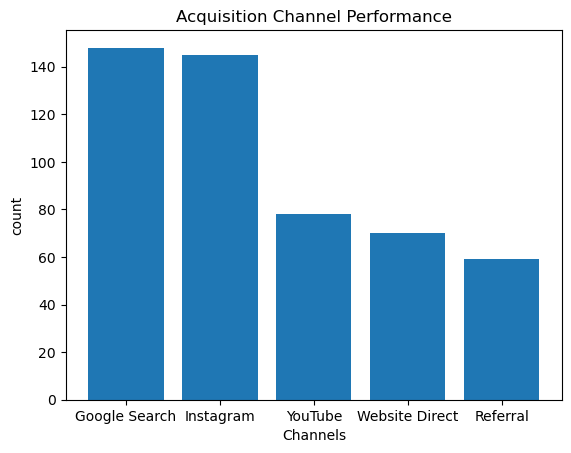

In [82]:
import matplotlib.pyplot as plt
import pandas as pd 

customers = pd.read_csv("Customers.csv")
count_data = customers.acquisition_channel.value_counts()
plt.bar(count_data.index, count_data.values)
plt.title("Acquisition Channel Performance")
plt.xlabel("Channels")
plt.ylabel("count")
plt.show()


#### This query and matplotlib identify and visualize which channels are drivng the greatest clientele for the company. This demonstrates the google search and instagram are the main sources driving attention to the company. Google searches acount for 27% (148 counts), Instagram accounts for a close following of 26% (145 counts), and youtube channels with 16% (78 counts). 

### Money

In [83]:
items.discount_pct.value_counts()

discount_pct
5     508
10    458
0     388
15    363
20    216
25    109
Name: count, dtype: int64

In [84]:
# discounts are done at all levels with the different products
query = """
SELECT products.product_name, products.category, items.discount_pct, items.unit_price, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price
FROM items
JOIN products
ON items.product_id = products.product_id
GROUP BY products.product_name, products.category, items.discount_pct
ORDER BY products.product_name DESC, products.category, items.discount_pct
LIMIT 50;
"""
result = pd.read_sql_query (query, conn)
result 

,product_name,category,discount_pct,unit_price,amt_purchased,total_price
0,Vitamin C 10% Face Serum,Serum,0,699,16,11184.00
1,Vitamin C 10% Face Serum,Serum,5,699,27,17929.35
2,Vitamin C 10% Face Serum,Serum,10,699,28,17614.80
3,Vitamin C 10% Face Serum,Serum,15,699,18,10694.70
4,Vitamin C 10% Face Serum,Serum,20,699,20,11184.00
5,Vitamin C 10% Face Serum,Serum,25,699,6,3145.50
6,Vitamin B5 Moisturizer,Moisturizer,0,399,22,8778.00
7,Vitamin B5 Moisturizer,Moisturizer,5,399,20,7581.00
8,Vitamin B5 Moisturizer,Moisturizer,10,399,27,9695.70
9,Vitamin B5 Moisturizer,Moisturizer,15,399,18,6104.70


In [85]:
# discounts are done at all levels with the different products
query = """
SELECT products.product_name, products.category, items.discount_pct, items.unit_price, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price
FROM items
JOIN products
ON items.product_id = products.product_id
GROUP BY products.product_name, products.category, items.discount_pct
ORDER BY products.product_name DESC, products.category, items.discount_pct
LIMIT 50;
"""
result = pd.read_sql_query (query, conn)
result 

,product_name,category,discount_pct,unit_price,amt_purchased,total_price
0,Vitamin C 10% Face Serum,Serum,0,699,16,11184.00
1,Vitamin C 10% Face Serum,Serum,5,699,27,17929.35
2,Vitamin C 10% Face Serum,Serum,10,699,28,17614.80
3,Vitamin C 10% Face Serum,Serum,15,699,18,10694.70
4,Vitamin C 10% Face Serum,Serum,20,699,20,11184.00
5,Vitamin C 10% Face Serum,Serum,25,699,6,3145.50
6,Vitamin B5 Moisturizer,Moisturizer,0,399,22,8778.00
7,Vitamin B5 Moisturizer,Moisturizer,5,399,20,7581.00
8,Vitamin B5 Moisturizer,Moisturizer,10,399,27,9695.70
9,Vitamin B5 Moisturizer,Moisturizer,15,399,18,6104.70


In [108]:
# discounts are done at all levels with the different products
#Note: Monetary values are reported in Indian Rupees, as provided in the original dataset.
query = """
SELECT product_name, category, unit_price, amt_purchased, total_price
FROM (
    SELECT products.product_name, products.category, items.discount_pct, items.unit_price, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price, ROW_NUMBER() OVER (PARTITION BY products.product_name ORDER BY SUM(items.quantity) DESC) as rn
    FROM items
    JOIN products
    ON items.product_id = products.product_id
    GROUP BY products.product_name, products.category, items.discount_pct, items.unit_price
) ranked
WHERE rn = 1
ORDER BY category, total_price DESC;
"""
result = pd.read_sql_query (query, conn)
result


,product_name,category,unit_price,amt_purchased,total_price
0,Body Lotion with Niacinamide,Body Care,449,23,9810.65
1,Body Wash with Salicylic Acid,Body Care,399,17,6104.70
2,Glycolic Acid Face Cleanser,Cleanser,349,36,11307.60
3,Salicylic Acid Face Cleanser,Cleanser,299,31,9269.00
4,Oat Extract Gentle Cleanser,Cleanser,299,19,5681.00
5,Caffeine Under Eye Cream,Eye Care,399,25,9476.25
6,Multi-Peptide Eye Cream,Eye Care,499,12,5988.00
7,Hair Growth Actives Serum,Hair Care,799,25,18976.25
8,Bond Repair Shampoo,Hair Care,599,25,14226.25
9,Anti-Dandruff Shampoo,Hair Care,499,14,6636.70


#### This query identifies the amount purchased for each product and the overall money earned from each product through summing the quantity for each item based on the amount of purchases made by discount level. Additionally, it identifies which products in each category (body care, serum, cleanser, etc) made the most money. In body care, Body Lotion with Niacinamide made the most money (9810.65 rupees). In cleansers, glycolic acid face cleanser made 11307.60 Rupees and so forth.

In [87]:
# Confirms the amt of discounted items matches the overall amount of orders for the company that is recorded
query = """
SELECT 
    SUM(amt_purchased)
FROM (
    SELECT products.product_name, products.category, items.discount_pct, items.unit_price, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price
    FROM items
    JOIN products
    ON items.product_id = products.product_id
    GROUP BY products.product_name, products.category, items.discount_pct, items.unit_price
    ORDER BY products.category, total_price DESC);
"""
result = pd.read_sql_query (query, conn)
result

,SUM(amt_purchased)
0,2579


##### Gross cost by Category

In [107]:
query = """
SELECT products.product_name, products.category, items.discount_pct, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price
FROM items
JOIN products
ON items.product_id = products.product_id
GROUP BY products.category
ORDER BY total_price DESC;
"""
result = pd.read_sql_query (query, conn)
result


,product_name,category,discount_pct,amt_purchased,total_price
0,2% Salicylic Acid Face Serum,Serum,10,919,540249.75
1,Ceramide Moisturizer,Moisturizer,5,443,155518.60
2,SPF 60 PA++++ Sunscreen,Sunscreen,15,314,129390.00
3,Anti-Dandruff Shampoo,Hair Care,15,216,128404.95
4,Oat Extract Gentle Cleanser,Cleanser,20,286,83094.55
5,Body Wash with Salicylic Acid,Body Care,10,128,49332.70
6,Caffeine Under Eye Cream,Eye Care,5,111,43829.15
7,Rose Water Hydrating Toner,Toner,0,80,27141.65
8,Lip Balm SPF 30,Lip Care,15,82,18388.65


#### This query identifies the revenue made by each category by summing quantity of products purchased and grouping by the categories in the product. The serum category is leading in first (540249.75 rupees) followed by moisturizers (1555518.60 rupees) and sunscreens (129390 rupees).

##### Gross cost by Discount level

In [106]:
#Confirmed total prices are consistent across the tables and no increase or decreases in total price.
query = """
SELECT items.discount_pct, SUM(items.quantity) as amt_purchased, SUM(items.item_total) AS total_price
FROM items
JOIN products
ON items.product_id = products.product_id
GROUP BY items.discount_pct
ORDER BY total_price DESC;
"""
result = pd.read_sql_query (query, conn)
result


,discount_pct,amt_purchased,total_price
0,5,642,307000.1
1,10,595,273694.5
2,0,487,241113.0
3,15,456,195452.4
4,20,265,109028.0
5,25,134,49062.0


#### This query identifies the amount purchased and total price across all discount levels (0, 5, 10, 15, 20, 25) through grouping discount percentages. The three discount percentages with the most purchased and most revenue was 5% (642 units purchased and revenue of 307000.1 rupees) followed by 10% (595 units purchased and revenue of 273694.5) and 0% (487 units purchased and 241113 rupees). This shows that there were more items purchased when there were 5% and 10% discount compared to the original price of the products.

In [90]:
## Tableau Dashboard

## Key Findings

* The most purchased category of skincare products were serums which made up 8 of the products out of the 28 offered by the company with 919 units purchased. Moisturizer make up the second most purchased product with 4 moisturizing products offered and 443 units purchased. Sunscreen makes up the third most purchased category with 3 total products offered and 314 units purchased. The least purchased category is the toners with 2 products offered and 80 units purchased. The second least purchased cateogry is lip care with 1 product offered and 82 units purchased. Serums are driving the most revenue in the company and the predominant skincare concerns are: anti-ageing (172 units purchased), pigmentation (166 units purchased), and oil control (144 units purchased).
* The most purchased type of skincare was alpha arbutin serum for pigmentation (166 units purchased) followed by niacinamide serum (144 units), SPF 60 sunscreen (138 units), and hyaluronic acid serum for hydration (132 units). The least purchased was an alcohol free toner (34 units), multi-peptide eye cream for anti-ageing (39 units), and rose water hydrating toner (46 units).
* When it come to skincare category, serums (919 units) are contributing the most to sales followed by moisturizers (443 units) and sunscreen (314).
* RATINGS: The two products with the highest rating are: Vitamin B5 moisturizer (4.5) and PHA 3% Alcohol-free toner (4.43). The two products with the lowest rating are: Body Wash with Salicylic Acid (3.25) and Anti-Dandruff Shampoo for dandruff control (3.28).¶
* CUSTOMERS: Maharashtra, Gujarat, and Madhya Pradesh are the top leading states when it comes to driving clientele. This could inform how acquisition channels are distributed towards different states in order to increase clientele.
* MONEY: 5% AND 10% discounts brought in the most revenue compared to the original pricing or higher discounts like 20% and 25%. Prioritizing 5% and 10% discounts over larger discounts initially may help to increase revenue from the products. Based on category and including discounts also helping to drive purchases, serums are leading with 919 units purchased and 540249.75, moisturizers with and 443 units purchased and 155518.60, and sunscreen with 129390.00 rupees. The 5% discounts brought in 307000.1 rupees leading in purchases and revenue followed by 10% with 595 units purchased and revenue of 273694.5 rupees, and 0% with 487 units purcahsesd and 241113 rupees in revenue. 

## Conclusion